---
title: "Global Adolescent Tobacco Use in 2022"
author: "Yigit Efe Bilgic"
date: "2026-04-15"
format:
  html:
    theme: cosmo
    fontsize: 1.2em
    embed-resources: true
    code-fold: true  
    echo: false       
---

In [67]:
import polars as pl

In [68]:
import plotly.express as px

In [69]:
import plotly.graph_objects as go

In [70]:
import plotly.io as pio

In [71]:
%%capture
!pip install kaleido==0.2.1 -q

In [72]:
!pip install polars statsmodels -q

In [73]:
import warnings

In [74]:
pio.renderers.default = "png"
warnings.filterwarnings('ignore')

In [75]:
df = pl.read_csv("cleaned_youth_smoking_2022.csv")

In [76]:
df_total = df.filter(pl.col("sex") == "Total")

In [77]:
df_wide = df.filter(pl.col("sex").is_in(["Male", "Female"])).pivot(
    index="country",
    on="sex",
    values="percentage"
)

In [78]:
top_5 = df_total.sort('percentage', descending=True).head(5)

In [79]:
df_gradient = df_total.sort("percentage").with_row_count("rank")

<div style="padding:30px; background-color:#8B0000; border-radius:15px; text-align:center;">
  <h1 style="color:white; font-family:serif; margin:0;">Global Adolescent Tobacco Use: 2022 Analysis</h1>
  <p style="color:#FFD700; font-style:italic; margin-top:10px;">A Comprehensive UNICEF Data Study</p>
  <hr style="border:0.5px solid white; width:50%; margin: 20px auto;">
  <p style="color:white; font-weight:bold;">Author: Yigit Efe Bilgic</p>
</div>
<br>
**Note on Report Format:** This notebook is optimized for GitHub rendering. All interactive visualizations are powered by Plotly and Polars.

<div style="padding:15px; border-left: 10px solid #8B0000; background-color: #f9f9f9; border-radius: 5px;">
  <h2 style="color:#8B0000; margin-top:0;">Executive Summary:</h2>
  This report provides a multi-dimensional analysis of global tobacco prevalence among adolescents (13-15).
  By investigating regional clusters and gender disparities, we identify where public health interventions
  are most urgently needed.
</div>

# 🎯 Project Overview

---

<div style="padding: 20px; background-color: #fdf2f2; border-radius: 10px; border: 1px solid #8B0000;">
  <p style="line-height: 1.8; color: #333; font-size: 16px;">
    This dashboard provides a multi-dimensional analysis of global tobacco prevalence among adolescents aged 13-15, utilizing <b>2022 UNICEF datasets</b>. Beyond mapping geographical distributions, this study is a critical response to the global nicotine crisis: it investigates the alarming rise in youth addiction, identifies high-risk regional clusters, and exposes a shifting paradigm where gender gaps are narrowing—and in some nations, reversed.
  </p>
  
  <p style="line-height: 1.8; color: #333; font-size: 16px;">
    Understanding these trends is paramount, as early-onset tobacco use serves as the primary driver for lifelong health complications and systemic economic burdens. By highlighting these disparities, this analysis provides the essential evidence base needed for urgent, <b>gender-specific policy interventions</b> and global prevention strategies.
  </p>
</div>

### 🔑 Key Study Pillars
* 📍 **Geographical Mapping:** Visualizing 2022 distribution.
* 📈 **Addiction Analysis:** Identifying high-risk regional clusters.
* ⚖️ **Gender Paradigms:** Investigating the narrowing prevalence gap.

---

<h3 style="background-color:#f1f1f1; padding:10px; border-radius:5px; border-bottom: 3px solid #8B0000;">
  🌍 1. Global Overview: Mapping the Crisis
</h3>

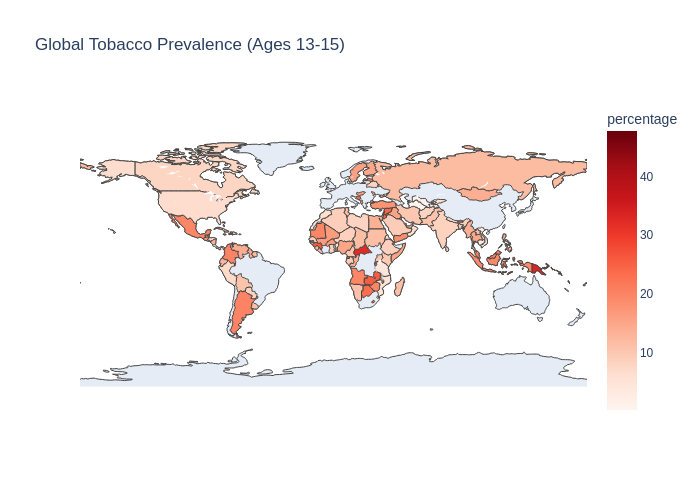

In [80]:
# @title Global Tobacco Prevalence Map
fig_map = px.choropleth(
    df_total.to_pandas(),
    locations="country",
    locationmode="country names",
    color="percentage",
    hover_name="country",
    color_continuous_scale="Reds",
    title="Global Tobacco Prevalence (Ages 13-15)"
)
fig_map.update_layout(geo=dict(showframe=False, projection_type='equirectangular'))
fig_map

<h3 style="background-color:#f1f1f1; padding:10px; border-radius:5px; border-bottom: 3px solid #8B0000;">
  📊 2. Worst Scenarios: High-Risk Regional Clusters (Top 5 Countries of Use)
</h3>

<div style="padding: 20px; border-left: 10px solid #8B0000; background-color: #fdf2f2; border-radius: 10px; line-height: 1.6;">

  <p style="color: #333;">
    Identification of high-prevalence clusters is essential for global prevention strategies. The following five nations represent the highest adolescent tobacco use recorded in the 2022 dataset.
  <p style="color: #333; font-size: 1.1em;">
    While tobacco use is a global challenge, the data reveals specific nations with <b>extreme prevalence rates</b> that demand immediate attention. Conversely, identifying regions with remarkably low figures—some reporting <b>below 1%</b>—is equally vital.
  </p>
  <p style="color: #333;">
    This variance suggests that local cultural factors or stringent public health policies (similar to the successful frameworks we observe here in <b>Ireland</b>) may be effectively deterring adolescent tobacco initiation. This chart highlights the most critical intervention points identified in the 2022 dataset.
  </p>

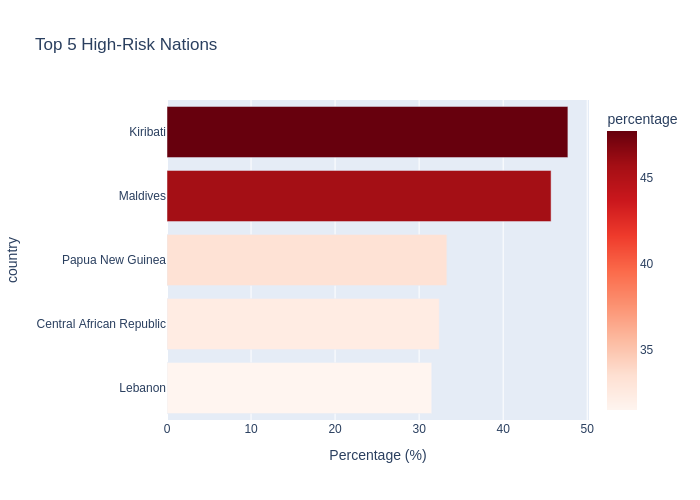

In [81]:
# @title  High-Risk Nations Analysis
top_5 = df_total.sort('percentage', descending=True).head(5)
fig_bar = px.bar(
    top_5.to_pandas(),
    x="percentage",
    y="country",
    orientation='h',
    color="percentage",
    color_continuous_scale="Reds",
    title="Top 5 High-Risk Nations"
)
fig_bar.update_layout(yaxis={'categoryorder':'total ascending'}, xaxis_title="Percentage (%)")
fig_bar

<h3 style="background-color:#f1f1f1; padding:10px; border-radius:5px; border-bottom: 3px solid #8B0000;">
  ⚖️ 3. The Gender Shift: A Rare Insight
</h3>

In many regions, adolescent girls now exhibit higher tobacco prevalence rates than their male counterparts. This scatterplot identifies these nations (those above the dashed line) and shows the global correlation.
<div
  <p style="color: #333; font-size: 1.1em;">
    In contrast to the prevailing global trend where male consumption is typically higher, these <b>13 identified nations</b> show a reversed pattern.
  </p>
  <p style="color: #333;">
    In these specific regions, <b>adolescent girls</b> exhibit higher tobacco prevalence rates than their male counterparts. This deviation from the norm highlights an urgent need for <b>gender-specific public health interventions</b> and a reassessment of traditional prevention strategies that have historically focused on male demographics.
  </p>

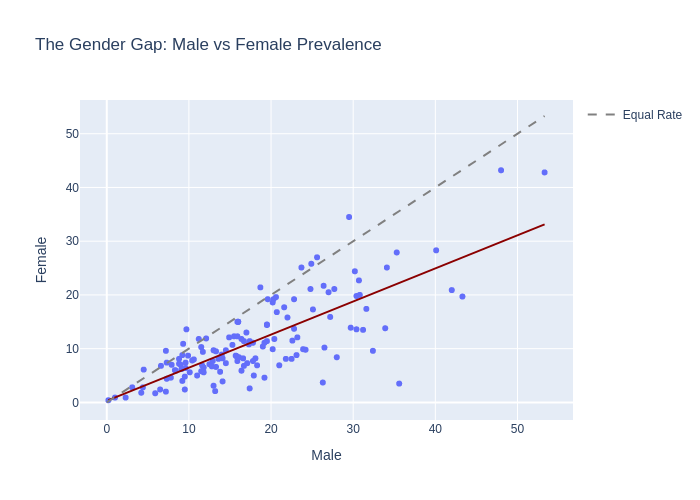

In [82]:
# @title Gender Gap Visualization
# Reshape data from long to wide format to compare Male vs Female
df_wide = df.filter(pl.col("sex").is_in(["Male", "Female"])).pivot(
    index="country",
    on="sex",
    values="percentage"
)

fig_scatter = px.scatter(
    df_wide.to_pandas(),
    x="Male",
    y="Female",
    hover_name="country",
    trendline="ols",
    trendline_color_override="darkred",
    title="The Gender Gap: Male vs Female Prevalence"
)

# Add 45-degree reference line
max_val = df_wide["Male"].max()
fig_scatter.add_trace(go.Scatter(x=[0, max_val], y=[0, max_val], mode="lines",
                                 line=dict(dash="dash", color="gray"), name="Equal Rate"))
fig_scatter

<h3 style="background-color:#f1f1f1; padding:10px; border-radius:5px; border-bottom: 3px solid #8B0000;">
  📈 4. The Global Distribution Curve
</h3>

This line chart visualizes the distribution of prevalence across all surveyed countries. By sorting the 2022 data from lowest to highest, we can identify the "slope" of the global crisis and see how a majority of nations cluster around the lower end, while a significant few experience extreme rates.

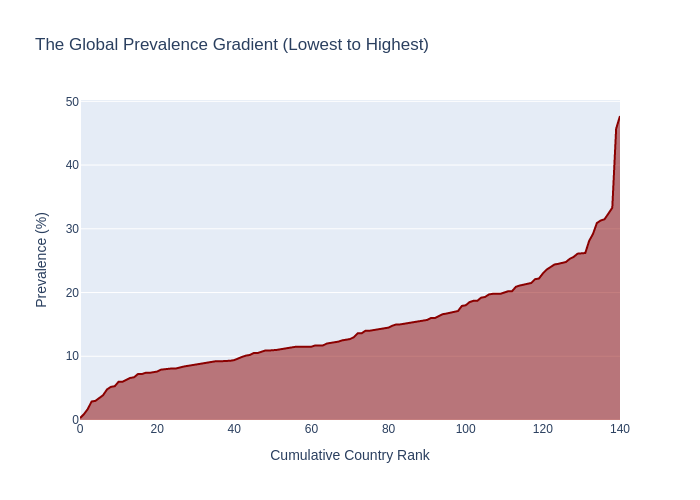

In [83]:
# @title Global Prevalence Gradient
# Sorting countries by percentage to create a distribution curve
df_gradient = df_total.sort("percentage").with_row_count("rank")

fig_line = px.line(
    df_gradient.to_pandas(),
    x="rank",
    y="percentage",
    hover_name="country",
    title="The Global Prevalence Gradient (Lowest to Highest)",
    labels={"rank": "Cumulative Country Rank", "percentage": "Prevalence (%)"}
)
fig_line.update_traces(line_color="darkred", fill='tozeroy')
fig_line.update_layout(xaxis_showgrid=False)
fig_line

<div style="padding:20px; background-color:#8B0000; color:white; border-radius:10px;">
  <h2 style="color:white; margin-top:0;">Strategic Conclusions</h2>
  <ul style="list-style-type:circle;">
    <li><b>Distribution Curve:</b> Targeted intervention must focus on the upper percentile of the curve.</li>
    <li><b>Gender Parity:</b> As prevalence increases, gender disparity often widens.</li>
    <li><b>Policy Target:</b> High-risk nations require immediate international support to protect the 13-15 age cohort.</li>
  </ul>
</div>

In [84]:
%%capture
pip install quarto-cli

In [85]:
%%capture
from google.colab import drive
drive.mount("/content/drive")

In [87]:
%%capture
!quarto render "/content/drive/MyDrive/Colab Notebooks/tobacco.ipynb"